In [1]:
import scanpy as sc
import scvi
import seaborn as sns
import numpy as np
import pandas as pd
import torch
from rich import print

/home/yeohs0212/anaconda3/envs/scvi-env/lib/python3.12/site-packages/docrep/decorators.py:43: SyntaxWarning: 'param_categorical_covariate_keys' is not a valid key!
  doc = func(self, args[0].__doc__, *args[1:], **kwargs)
/home/yeohs0212/anaconda3/envs/scvi-env/lib/python3.12/site-packages/docrep/decorators.py:43: SyntaxWarning: 'param_continuous_covariate_keys' is not a valid key!
  doc = func(self, args[0].__doc__, *args[1:], **kwargs)


In [114]:
scvi.settings.seed = 22
print("Last run with scvi-tools version:", scvi.__version__)

Seed set to 22


Last run with scvi-tools version: 1.3.0

In [3]:
# Setting params

torch.set_float32_matmul_precision("high")

In [4]:
adata = sc.read_h5ad('/data/yeohs0212/MM/GSE207938/01_cell_type_anndata.h5ad')
adata

AnnData object with n_obs × n_vars = 28131 × 16826
    obs: 'batch', 'condition', 'cluster', 'cell_type', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
    uns: 'batch_colors', 'cell_type_colors'
    obsm: 'X_EMBED', 'X_PCA'
    layers: 'counts', 'data'

In [5]:
print(adata.X[1:20])

[[1 2 1 ... 1 0 0]
 [1 3 0 ... 4 1 0]
 [1 2 0 ... 6 0 2]
 ...
 [1 1 0 ... 1 0 0]
 [1 4 0 ... 3 0 1]
 [0 2 0 ... 3 2 0]]

In [6]:
import re

# 파일 읽기
with open("/data/yeohs0212/basic/human_cellcycle_s_genelist.txt", 'r') as f:
    content = f.read()

# 정규표현식을 사용해 따옴표 안의 글자나 단어만 추출
# 이 방식은 쉼표, 줄바꿈, 공백이 섞여 있어도 유전자 이름만 정확히 가져옵니다.
genes_s = re.findall(r'(\w+)', content)

with open("/data/yeohs0212/basic/human_cellcycle_g2m_genelist.txt", 'r') as f:
    content = f.read()

# 정규표현식을 사용해 따옴표 안의 글자나 단어만 추출
# 이 방식은 쉼표, 줄바꿈, 공백이 섞여 있어도 유전자 이름만 정확히 가져옵니다.
genes_g2m = re.findall(r'(\w+)', content)
print(genes_s)
print(genes_g2m)


[
    'MCM5',
    'PCNA',
    'TYMS',
    'FEN1',
    'MCM7',
    'MCM4',
    'RRM1',
    'UNG',
    'GINS2',
    'MCM6',
    'CDCA7',
    'DTL',
    'PRIM1',
    'UHRF1',
    'CENPU',
    'HELLS',
    'RFC2',
    'POLR1B',
    'NASP',
    'RAD51AP1',
    'GMNN',
    'WDR76',
    'SLBP',
    'CCNE2',
    'UBR7',
    'POLD3',
    'MSH2',
    'ATAD2',
    'RAD51',
    'RRM2',
    'CDC45',
    'CDC6',
    'EXO1',
    'TIPIN',
    'DSCC1',
    'BLM',
    'CASP8AP2',
    'USP1',
    'CLSPN',
    'POLA1',
    'CHAF1B',
    'MRPL36',
    'E2F8'
]

[
    'HMGB2',
    'CDK1',
    'NUSAP1',
    'UBE2C',
    'BIRC5',
    'TPX2',
    'TOP2A',
    'NDC80',
    'CKS2',
    'NUF2',
    'CKS1B',
    'MKI67',
    'TMPO',
    'CENPF',
    'TACC3',
    'PIMREG',
    'SMC4',
    'CCNB2',
    'CKAP2L',
    'CKAP2',
    'AURKB',
    'BUB1',
    'KIF11',
    'ANP32E',
    'TUBB4B',
    'GTSE1',
    'KIF20B',
    'HJURP',
    'CDCA3',
    'JPT1',
    'CDC20',
    'TTK',
    'CDC25C',
    'KIF2C',
    'RANGAP1',
    'NCAPD2',
    'DLGAP5',
    'CDCA2',
    'CDCA8',
    'ECT2',
    'KIF23',
    'HMMR',
    'AURKA',
    'PSRC1',
    'ANLN',
    'LBR',
    'CKAP5',
    'CENPE',
    'CTCF',
    'NEK2',
    'G2E3',
    'GAS2L3',
    'CBX5',
    'CENPA'
]

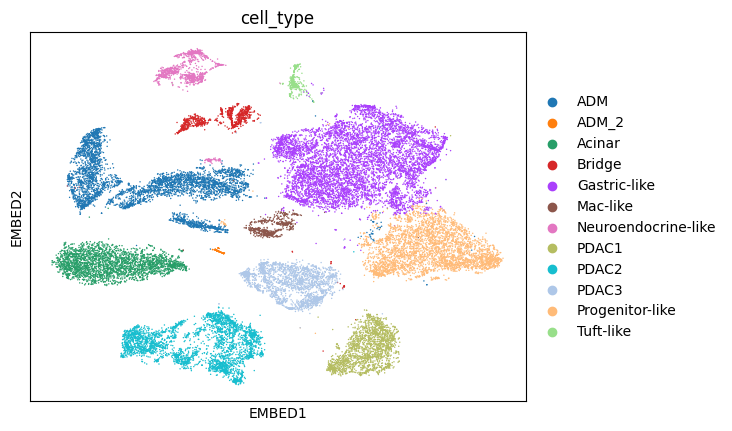

In [7]:
sc.pl.embedding(adata, basis = 'EMBED', color = 'cell_type')

In [8]:

target_cells = ['ADM', 'Acinar', 'Bridge', 'PDAC1', 'PDAC2', 'PDAC3']

adata = adata[adata.obs['cell_type'].isin(target_cells), :].copy()

print(adata.obs['cell_type'].value_counts())

cell_type
ADM       4393
PDAC2     3374
Acinar    2783
PDAC3     2135
PDAC1     1950
Bridge     927
ADM_2      105
Name: count, dtype: int64

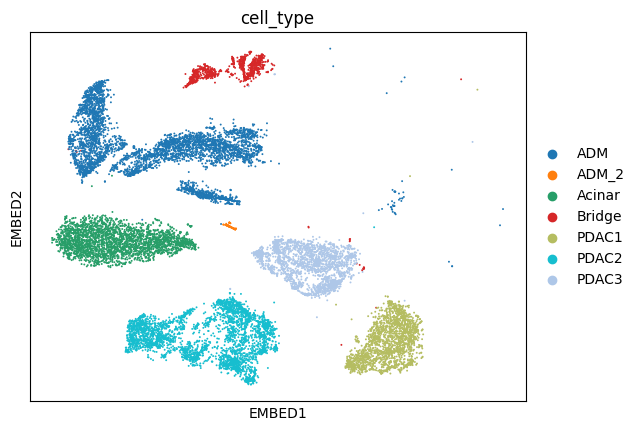

In [9]:
sc.pl.embedding(adata, basis = 'EMBED', color = 'cell_type')

In [10]:
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)
sc.tl.score_genes_cell_cycle(adata, g2m_genes=genes_g2m, s_genes=genes_s)

In [12]:
adata.obs['batch'].value_counts()

batch
Ag-PDAC-PT-Kate        2215
DAC_D020_p5_Epi        2127
DACD550_kate_plus      1803
DACC963LIVERmet        1747
DAC_B530-Kate+         1606
DACC963_mKate_plus     1441
DACD511_Kate_plus      1081
DACD403_Kate_plus       575
DACD351_Kate_plus       517
Ag-Lung-Mets-Kate       302
DACD394_Kate_plus       298
DAC_DI143_Epi           290
DACD407_Kate_plus       281
DACD406_Kate_plus       268
DAC_C263_EPI            241
DACC963PT_Kate_plus     237
DACD482_Kate_plus       220
D396_EPI                216
DACD404_Kate_plus       125
DAC_C301-EPI_2           41
DAC_C301-EPI_1           36
Name: count, dtype: int64

In [13]:
sc.pp.highly_variable_genes(
    adata,
    flavor="seurat_v3",
    n_top_genes=3000,
    layer="counts",
    batch_key="batch",
    subset=True,
    span = 0.7
)

In [78]:
# 1. 기존의 세분화된 cell_type을 'cell_type_res2'라는 이름으로 복사해둡니다.
adata.obs['cell_type_res2'] = adata.obs['cell_type'].copy()

# 2. 변경할 매핑 정보를 딕셔너리로 만듭니다.
# 묶이지 않는 나머지(Acinar, Bridge 등)는 그대로 유지됩니다.
rename_map = {
    "ADM_2": "ADM",
    "PDAC1": "PDAC",
    "PDAC2": "PDAC",
    "PDAC3": "PDAC"
}

# 3. .replace()를 사용하여 'cell_type' 컬럼의 값들을 통합합니다.
# 이 방법은 딕셔너리에 없는 값들은 건드리지 않고 그대로 둡니다.
adata.obs['cell_type'] = adata.obs['cell_type'].replace(rename_map)

# 4. 결과 확인
print("--- 변경 후 cell_type 분포 ---")
print(adata.obs['cell_type'].value_counts())

print("\n--- 보존된 cell_type_res2 분포 ---")
print(adata.obs['cell_type_res2'].value_counts())

/tmp/ipykernel_4010577/1877684029.py:15: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  adata.obs['cell_type'] = adata.obs['cell_type'].replace(rename_map)


--- 변경 후 cell_type 분포 ---

cell_type
PDAC      7459
ADM       4498
Acinar    2783
Bridge     927
Name: count, dtype: int64

--- 보존된 cell_type_res2 분포 ---

cell_type_res2
ADM       4393
PDAC2     3374
Acinar    2783
PDAC3     2135
PDAC1     1950
Bridge     927
ADM_2      105
Name: count, dtype: int64

In [119]:
adata

AnnData object with n_obs × n_vars = 15667 × 3000
    obs: 'batch', 'condition', 'cluster', 'cell_type', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'S_score', 'G2M_score', 'phase', '_scvi_batch', '_scvi_labels', 'cell_type_res2'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'batch_colors', 'cell_type_colors', 'log1p', 'hvg', '_scvi_uuid', '_scvi_manager_uuid', 'neighbors', 'umap', 'cell_type_res2_colors'
    obsm: 'X_EMBED', 'X_PCA', '_scvi_extra_categorical_covs', '_scvi_extra_continuous_covs', 'X_scVI', 'X_umap'
    layers: 'counts', 'data'
    obsp: 'distances', 'connectivities'

In [120]:
scvi.settings.seed = 42

Seed set to 42


In [122]:
scvi.model.SCVI.setup_anndata(
    adata, 
    layer="counts", 
    #batch_key="batch", # 배치는 섞어주고
    #categorical_covariate_keys=["condition"], # 실험 조건(Control vs Treat 등)만 보정
    continuous_covariate_keys=['total_counts', 'S_score', 'G2M_score'] # 기술적 요인 보정
)

In [123]:
model = scvi.model.SCVI(adata, n_layers=2, n_latent=30)

In [124]:
model.train(early_stopping=True, 
            early_stopping_patience=10,
            check_val_every_n_epoch=2)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/yeohs0212/anaconda3/envs/scvi-env/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=111` in the `DataLoader` to improve performance.
/home/yeohs0212/anaconda3/envs/scvi-env/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=111` in the `DataLoader` to improve performance.


Training:   0%|          | 0/400 [00:00<?, ?it/s]

Monitored metric elbo_validation did not improve in the last 10 records. Best score: 2188.326. Signaling Trainer to stop.


In [125]:
adata

AnnData object with n_obs × n_vars = 15667 × 3000
    obs: 'batch', 'condition', 'cluster', 'cell_type', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'S_score', 'G2M_score', 'phase', '_scvi_batch', '_scvi_labels', 'cell_type_res2'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'batch_colors', 'cell_type_colors', 'log1p', 'hvg', '_scvi_uuid', '_scvi_manager_uuid', 'neighbors', 'umap', 'cell_type_res2_colors'
    obsm: 'X_EMBED', 'X_PCA', '_scvi_extra_categorical_covs', '_scvi_extra_continuous_covs', 'X_scVI', 'X_umap'
    layers: 'counts', 'data'
    obsp: 'distances', 'connectivities'

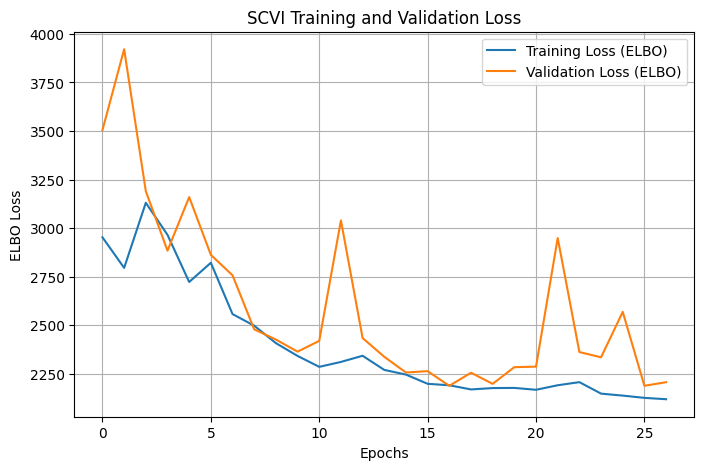

In [126]:
import matplotlib.pyplot as plt

train_loss = model.history["elbo_train"]
val_loss = model.history["elbo_validation"]

plt.figure(figsize=(8, 5))
plt.plot(train_loss, label="Training Loss (ELBO)")
plt.plot(val_loss, label="Validation Loss (ELBO)")
plt.xlabel("Epochs")
plt.ylabel("ELBO Loss")
plt.title("SCVI Training and Validation Loss")
plt.legend()
plt.grid()
plt.show()

In [127]:
SCVI_LATENT_KEY = "X_scVI"
adata.obsm[SCVI_LATENT_KEY] = model.get_latent_representation()


In [138]:
sc.pp.neighbors(adata, use_rep=SCVI_LATENT_KEY)
sc.tl.umap(adata)

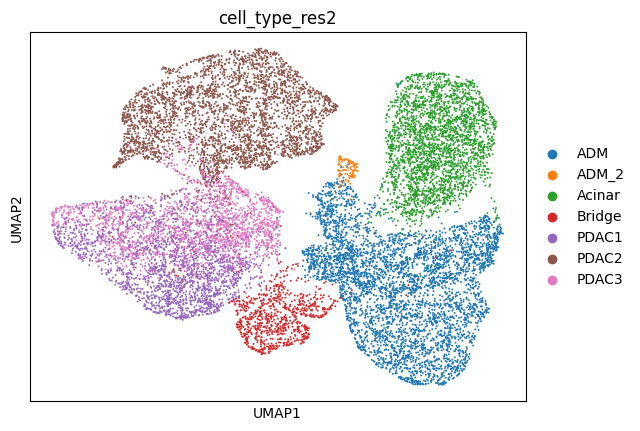

In [139]:
sc.pl.umap(adata, color = ['cell_type_res2'])

In [137]:
adata.write('/data/yeohs0212/MM/GSE207938/02_ADM_PDAC_subset.h5ad')